# Vessel Delay Prediction Model
Model - Random Forest model

Author - Yan

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
)

## Load Data and Check Data

In [3]:
df = pd.read_csv(r"E:\Projects\Singapore port project\Cleaned Dataset\singapore_view.csv")
print(f"Loaded dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")

Loaded dataset: 609,468 rows, 24 columns


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 609468 entries, 0 to 609467
Data columns (total 24 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   callsign                  609468 non-null  int64  
 1   eta_day                   609468 non-null  int64  
 2   eta_hour                  599435 non-null  float64
 3   eta_min                   599448 non-null  float64
 4   eta_month                 609468 non-null  int64  
 5   imo_number                609468 non-null  int64  
 6   maximim_draught           609468 non-null  float64
 7   vessel_code               609468 non-null  int64  
 8   vessel_type               609468 non-null  object 
 9   mmsi                      609468 non-null  int64  
 10  ship_name                 609468 non-null  int64  
 11  geom                      609468 non-null  object 
 12  ship_data_id              609468 non-null  int64  
 13  date                      609468 non-null  o

## Create Delay Label

In [5]:
# Removing rows : invalid ETA month
df = df[df["eta_month"] > 0].copy()

# Converting data type to date
df["date"] = pd.to_datetime(df["date"])

# Create day column
df["day"] = df["date"].dt.day


In [6]:
# Delay = 1 if arrival day > ETA
df["delay"] = np.where(df["day"] > df["eta_day"],1,0)

print(f"\nDelay distribution:")
print(df["delay"].value_counts())
print(f"Overall delay rate: {df['delay'].mean()*100:.1f}%")


Delay distribution:
delay
0    332095
1    255748
Name: count, dtype: int64
Overall delay rate: 43.5%


## Features Engineering

In [8]:
# Time feature

df["day_of_week"] = df["date"].dt.dayofweek

In [9]:
# Speed feature

def speed_category(speed):
    if speed < 0.5:
        return "moored"
    elif speed <= 5:
        return "slow"
    else:
        return "underway"

df["speed_cat"] = df["speed"].apply(speed_category)

        

In [10]:
# Vessel types feature

df["vessel_type_simple"] = df["vessel_type"].str.lower()
df["vessel_type_simple"] = np.where( df["vessel_type_simple"].str.contains("cargo"), "cargo",
                           np.where(df["vessel_type_simple"].str.contains("tanker"), "tanker", "other") )

In [11]:
# Filling missing values for true_heading
# Fill with COG as proxy

df["true_heading"] = pd.to_numeric(df["true_heading"], errors = "coerce")
df["true_heading"] = df["true_heading"].fillna(df["cog"])




In [12]:
# Draught feature
# Fill nulls with median

df["maximim_draught"] = df["maximim_draught"].fillna(df["maximim_draught"].median())


## Select Features

In [13]:
FEATURES = [
    # Numeric
    "speed",
    "day_of_week",
    "eta_hour",
    "eta_min",
    "week_number",
    "cog",
    "maximim_draught",
    "latitude",
    "longitude",
    # Categorical 
    "speed_cat",
    "vessel_type_simple",
    "direction",
    "navigational_status",
]

X = df[FEATURES].copy()
y = df["delay"]

## Encode Categorical columns

In [14]:
# One-hot encoding
X = pd.get_dummies(
    X,
    columns = ["speed_cat", "vessel_type_simple", "direction", "navigational_status"],
    drop_first=True,
)


In [15]:
# Safety fill for any remaining nulls
X = X.fillna(0)

print(f"\nFeature matrix shape: {X.shape}")
print(f"Features used: {X.columns.tolist()}")


Feature matrix shape: (587843, 31)
Features used: ['speed', 'day_of_week', 'eta_hour', 'eta_min', 'week_number', 'cog', 'maximim_draught', 'latitude', 'longitude', 'speed_cat_slow', 'speed_cat_underway', 'vessel_type_simple_tanker', 'direction_N', 'direction_NE', 'direction_NW', 'direction_S', 'direction_SE', 'direction_SW', 'direction_W', 'navigational_status_At anchor', 'navigational_status_Constrained by her draught', 'navigational_status_Moored', 'navigational_status_Not under command', 'navigational_status_Power-driven vessel pushing ahead or towing alongside', 'navigational_status_Power-driven vessel towing astern', 'navigational_status_Reserved for future use (HSC)', 'navigational_status_Reserved for future use (WIG)', 'navigational_status_Restricted manoeuvrability', 'navigational_status_Undefined (default)', 'navigational_status_Under way sailing', 'navigational_status_Under way using engine']


## Train / Test Spliting ( 70% Train, 30% test )

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state = 42          # Test size = 0.3 = 30%
)

print(f"\nTraining set : {X_train.shape[0]:,} rows")
print(f"Test set     : {X_test.shape[0]:,} rows")


Training set : 411,490 rows
Test set     : 176,353 rows


## Training Random Forest Model 

In [19]:
model = RandomForestClassifier(
    n_estimators = 100,
    max_depth = 12,
    min_samples_leaf = 10,
    random_state = 42,
    n_jobs = -1,
)

print("\nTraining model...")
model.fit(X_train, y_train)
print("Training complete.")


Training model...
Training complete.


## Evaluate Model

In [21]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
 
accuracy = (y_pred == y_test).mean() * 100
auc      = roc_auc_score(y_test, y_prob) * 100
 
print("\n" + "="*50)
print(f"  ACCURACY : {accuracy:.2f}%")
print(f"  AUC ROC  : {auc:.2f}%")
print("="*50)
 

print(classification_report(y_test, y_pred, target_names=["On time", "Delayed"]))


  ACCURACY : 77.05%
  AUC ROC  : 85.36%
              precision    recall  f1-score   support

     On time       0.79      0.80      0.80     99360
     Delayed       0.74      0.73      0.73     76993

    accuracy                           0.77    176353
   macro avg       0.77      0.77      0.77    176353
weighted avg       0.77      0.77      0.77    176353



## Visualizations

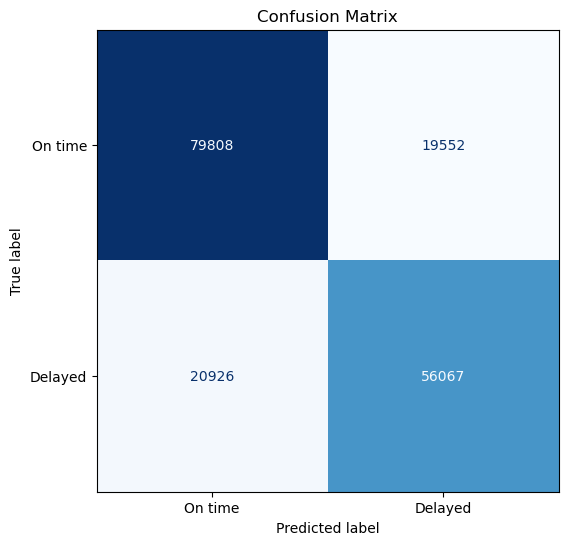

In [37]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 6)) 
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["On time", "Delayed"])
disp.plot(ax=ax, colorbar=False, cmap="Blues", values_format='d') 
ax.set_title("Confusion Matrix")
plt.show()

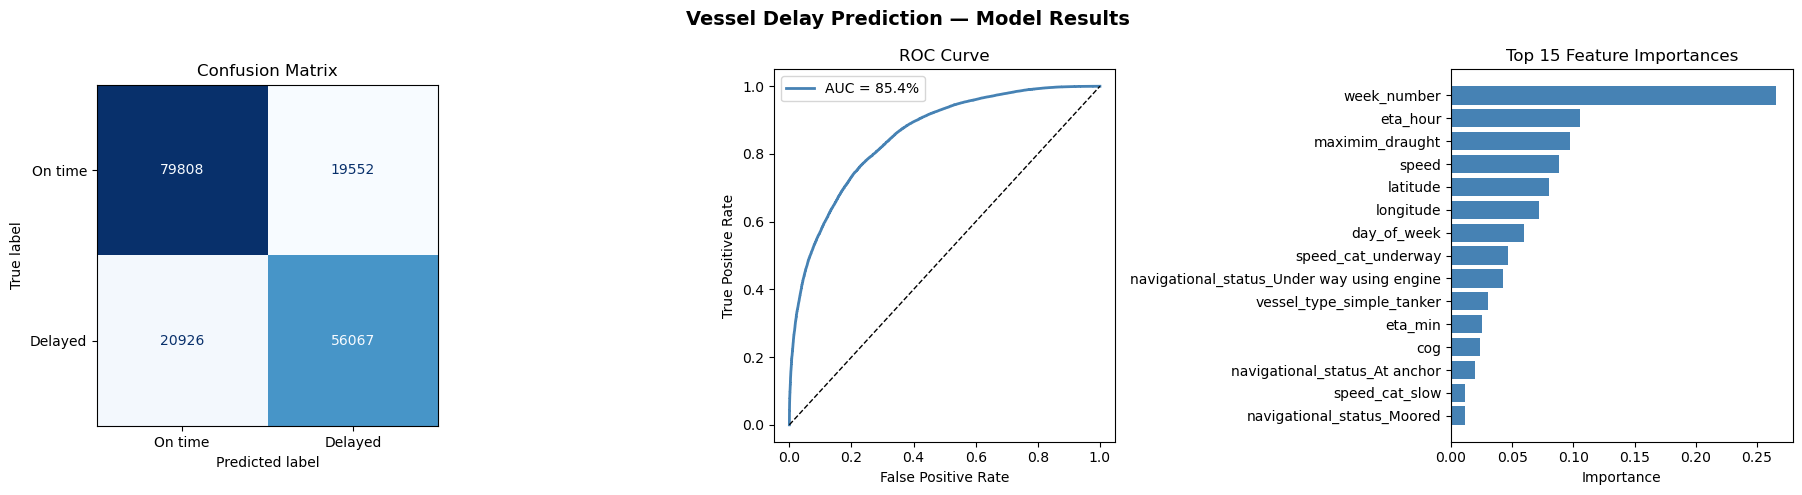

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Vessel Delay Prediction — Model Results", fontsize=14, fontweight="bold")
 
# Plot 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["On time", "Delayed"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues", values_format = 'd')
axes[0].set_title("Confusion Matrix")
 
# Plot 2: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color="steelblue", lw=2, label=f"AUC = {auc:.1f}%")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()
 
# Plot 3: Top 15 Feature Importances
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_,
}).sort_values("Importance", ascending=True).tail(15)
 
axes[2].barh(importance_df["Feature"], importance_df["Importance"], color="steelblue")
axes[2].set_xlabel("Importance")
axes[2].set_title("Top 15 Feature Importances")
 
plt.tight_layout()
plt.savefig("vessel_delay_results.png", dpi=150, bbox_inches="tight")
plt.show()



In [41]:
import os; os.getcwd()

'C:\\Users\\Asus\\Singapore Port Analysis'

## Saving Model

In [44]:
joblib.dump(model, "vessel_delay_model.pkl")
joblib.dump(list(X.columns), "vessel_delay_features.pkl")

['vessel_delay_features.pkl']